In [1]:
import pandas as pd
from scipy.fft import rfft, rfftfreq
import numpy as np

In [2]:
# load the data from the CSV file
data_file = 'data/accel_data.csv'
data = pd.read_csv(data_file)
data

,pc_time,packet_counter,arduino_time_us,ax_raw,ay_raw,az_raw
0,1.778374e+09,0,2008,0.074824,0.053494,1.028092
1,1.778374e+09,0,40124,0.077169,0.051149,1.028092
2,1.778374e+09,0,78224,0.077169,0.053494,1.028092
3,1.778374e+09,1,116900,0.077169,0.053494,1.028092
4,1.778374e+09,1,155020,0.074824,0.053494,1.028092
...,...,...,...,...,...,...
208,1.778374e+09,69,7968948,0.005637,0.049975,1.031617
209,1.778374e+09,69,8007060,0.010329,0.047629,1.027051
210,1.778374e+09,70,8045732,0.006813,0.048804,1.030374
211,1.778374e+09,70,8083856,0.007983,0.052320,1.031617


In [3]:
# get avg frequency of samples
time_between_samples = data['arduino_time_us'].diff().dropna()
avg_freq = 1 / (10 ** -6 * time_between_samples.mean())
avg_freq

np.float64(26.108490136163162)

In [4]:
list(data['arduino_time_us'].diff())[0:50]

[nan,
 38116.0,
 38100.0,
 38676.0,
 38120.0,
 38112.0,
 38676.0,
 38112.0,
 38120.0,
 38680.0,
 38120.0,
 38124.0,
 38668.0,
 38132.0,
 38112.0,
 38676.0,
 38124.0,
 38112.0,
 38684.0,
 38116.0,
 38120.0,
 38672.0,
 38120.0,
 38108.0,
 38692.0,
 38120.0,
 38124.0,
 38672.0,
 38128.0,
 38116.0,
 38672.0,
 38128.0,
 38112.0,
 38676.0,
 38116.0,
 38116.0,
 38684.0,
 38116.0,
 38124.0,
 38672.0,
 38128.0,
 38112.0,
 38676.0,
 38124.0,
 38112.0,
 38684.0,
 38116.0,
 38120.0,
 38672.0,
 38120.0]

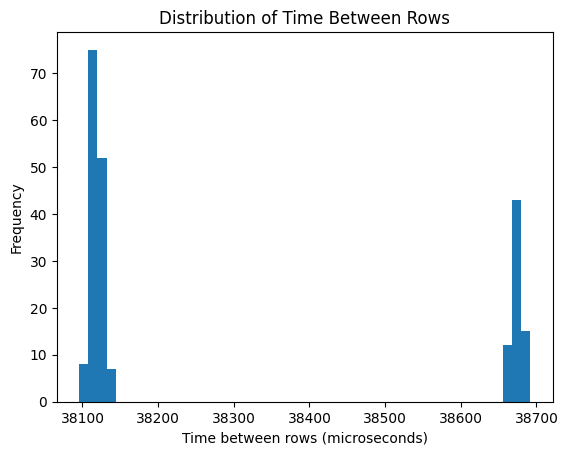

In [5]:
# plot the distribution of t_us between rows
import matplotlib.pyplot as plt
plt.hist(data['arduino_time_us'].diff().dropna(), bins=50)
plt.xlabel('Time between rows (microseconds)')
plt.ylabel('Frequency')
plt.title('Distribution of Time Between Rows')
plt.show()

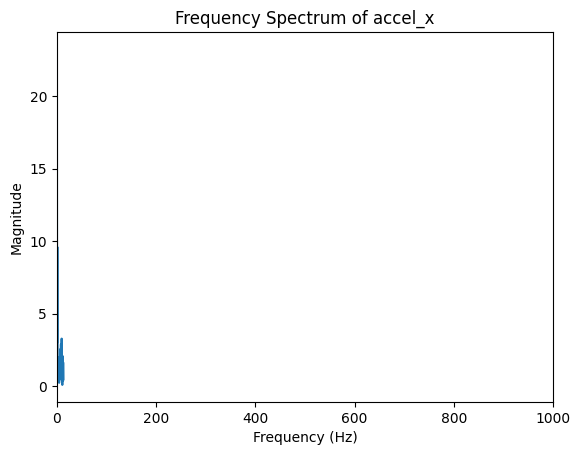

In [6]:
# perform frequency analysis on accel data
# Number of samples
N = len(data)
# Sample spacing
T = 1 / avg_freq
# Perform FFT on accel_x
yf = rfft(data['ax_raw'])
xf = rfftfreq(N, T)
plt.plot(xf, np.abs(yf))
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.title('Frequency Spectrum of accel_x')
plt.xlim(0, 1000)  # Limit x-axis to 1000 Hz
plt.show()